# Lasso
**Statistical Modeling - Session 10**

Wir sehen, was passiert, wenn viele Pradiktoren irrelevant sind, und wie Lasso
automatisch die wichtigen auswahlt -- mit dem Tuning-Parameter $\lambda$ aus der
Kreuzvalidierung.

*Hinweis:* scikit-learn nennt $\lambda$ in den Modellen `alpha`.

In [28]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, LassoCV, Lasso, Ridge, lasso_path
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.model_selection import KFold
from matplotlib.patches import Circle, Polygon

rng = 42

## 1. Daten: 30 Pradiktoren -- aber nur 5 sind echt

Wir erzeugen Daten, bei denen nur 5 der 30 Variablen wirklich einen Effekt haben.
Die restlichen 15 sind reines Rauschen. Ein gutes Verfahren sollte das erkennen.

In [2]:
X, y, true_coef = make_regression(
    n_samples=120, n_features=30, n_informative=5,
    noise=15.0, coef=True, random_state=rng)

# Pradiktoren standardisieren -- der Strafterm ist skalenabhaengig!
X = StandardScaler().fit_transform(X)
p = X.shape[1]

echte_variablen = np.flatnonzero(true_coef)
print("Wahre relevante Variablen:", echte_variablen)

Wahre relevante Variablen: [ 8 20 24 26 27]


## 2. Was macht OLS? -- alle 20 Koeffizienten sind $\neq 0$

OLS kennt keinen Strafterm. Auch die 15 Rausch-Variablen bekommen einen
(zufaelligen) Koeffizienten ungleich null.

In [3]:
ols = LinearRegression().fit(X, y)
print("Koeffizienten != 0 bei OLS:", int(np.sum(np.abs(ols.coef_) > 1e-8)), f"von {p}")
print("OLS-Koeffizienten (gerundet):")
print(np.round(ols.coef_, 1))

Koeffizienten != 0 bei OLS: 30 von 30
OLS-Koeffizienten (gerundet):
[-1.   2.4  0.9 -1.8 -0.1 -0.8  3.4  1.2 80.8 -1.3  0.8 -2.8  0.6  0.7
  0.6 -1.4 -1.7 -1.1 -1.  -1.7 50.2 -0.  -1.4 -0.4 23.5  1.1 11.3 26.
  0.1 -1.7]


In [4]:
# 1. Konstante (Intercept) zu X hinzufügen, um das Verhalten von scikit-learn zu spiegeln
X_with_constant = sm.add_constant(X)

# 2. OLS-Modell fitten (Achtung: Bei statsmodels kommt y zuerst!)
ols_sm = sm.OLS(y, X_with_constant).fit()

# 3. Koeffizienten extrahieren 
# [1:] schließt die hinzugefügte Konstante aus, um nur die echten Variablen (wie bei ols.coef_) zu prüfen
coefficients = ols_sm.params[1:] 

# 4. Ausgabe analog zu deinem Screenshot
print("Koeffizienten != 0 bei OLS:", int(np.sum(np.abs(coefficients) > 1e-8)), f"von {p}")
print("OLS-Koeffizienten (gerundet):")
print(np.round(coefficients, 1))

Koeffizienten != 0 bei OLS: 30 von 30
OLS-Koeffizienten (gerundet):
[-1.   2.4  0.9 -1.8 -0.1 -0.8  3.4  1.2 80.8 -1.3  0.8 -2.8  0.6  0.7
  0.6 -1.4 -1.7 -1.1 -1.  -1.7 50.2 -0.  -1.4 -0.4 23.5  1.1 11.3 26.
  0.1 -1.7]


In [5]:
# 4. alternativ: Die vollständige statistische Tabelle ausgeben
print(ols_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     192.1
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.19e-68
Time:                        08:09:43   Log-Likelihood:                -473.99
No. Observations:                 120   AIC:                             1010.
Df Residuals:                      89   BIC:                             1096.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6397      1.332      3.483      0.0

## 3. Lasso waehlt aus -- $\lambda$ per Kreuzvalidierung

`LassoCV` probiert viele Werte fuer $\lambda$ durch und waehlt per 5-facher
Kreuzvalidierung den, der den Testfehler minimiert.

In [6]:
lasso_cv = LassoCV(cv=5, random_state=rng).fit(X, y)
lam = lasso_cv.alpha_
print(f"Gewaehltes lambda (alpha): {lam:.3f}\n")

ausgewaehlt = np.flatnonzero(np.abs(lasso_cv.coef_) > 1e-8)
print("Von Lasso ausgewaehlt:", ausgewaehlt)
print("Wahre relevante Var.: ", echte_variablen)
print("Anzahl != 0:", len(ausgewaehlt), f"von {p}")

Gewaehltes lambda (alpha): 1.494

Von Lasso ausgewaehlt: [ 2  6  8 11 16 19 20 24 26 27]
Wahre relevante Var.:  [ 8 20 24 26 27]
Anzahl != 0: 10 von 30


In [7]:
# 1. Konstante hinzufügen (wie bei OLS)
X_with_constant = sm.add_constant(X)

# 2. Grid von Alpha-Werten definieren, die durchprobiert werden sollen
# (LassoCV macht das im Hintergrund automatisch)
alphas = np.logspace(-3, 1, 10)

# 3. 5-fache Kreuzvalidierung manuell aufsetzen
kf = KFold(n_splits=5, shuffle=True, random_state=rng)
best_alpha = None
min_mse = float("inf")

# Schleife über alle Alphas, um den Testfehler (MSE) zu minimieren
for alpha in alphas:
    mse_list = []
    for train_idx, test_idx in kf.split(X_with_constant):
        X_train, X_test = X_with_constant[train_idx], X_with_constant[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Lasso in statsmodels: L1_wt=1.0 erzwingt reines Lasso
        model = sm.OLS(y_train, X_train).fit_regularized(alpha=alpha, L1_wt=1.0)
        
        # Vorhersage & Fehler berechnen
        preds = model.predict(X_test)
        mse = np.mean((y_test - preds) ** 2)
        mse_list.append(mse)
        
    avg_mse = np.mean(mse_list)
    if avg_mse < min_mse:
        min_mse = avg_mse
        best_alpha = alpha

print(f"Gewaehltes lambda (alpha): {best_alpha:.3f}\n")

# 4. Finales Modell mit dem besten Alpha auf den kompletten Daten fitten
final_model = sm.OLS(y, X_with_constant).fit_regularized(alpha=best_alpha, L1_wt=1.0)

# 5. Ausgewählte Variablen bestimmen (ohne den Intercept an Index 0)
coefficients = final_model.params[1:]
ausgewaehlt = np.flatnonzero(np.abs(coefficients) > 1e-8)

print("Von Lasso ausgewaehlt:", ausgewaehlt)
print("Wahre relevante Var.: ", echte_variablen)
print("Anzahl != 0:", len(ausgewaehlt), f"von {p}")

Gewaehltes lambda (alpha): 0.464

Von Lasso ausgewaehlt: [ 1  2  3  5  6  8 10 11 12 15 16 19 20 22 24 26 27 28 29]
Wahre relevante Var.:  [ 8 20 24 26 27]
Anzahl != 0: 19 von 30


## 4. Der Regularisierungspfad

Wie wandern die Koeffizienten gegen null, wenn $\lambda$ waechst? Die fett
gezeichneten Linien sind die 5 echten Variablen.

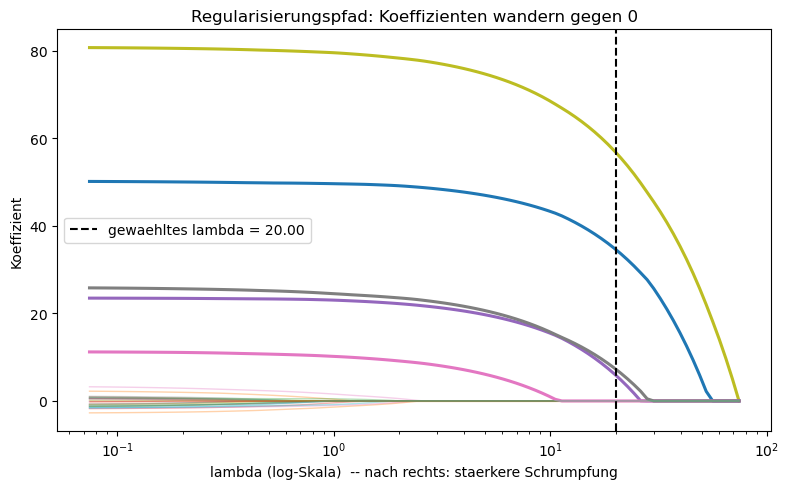

In [16]:
alphas, coefs, _ = lasso_path(X, y)

plt.figure(figsize=(8, 5))
for j in range(coefs.shape[0]):
    echt = j in echte_variablen
    plt.plot(alphas, coefs[j], lw=2.2 if echt else 1.0, alpha=1.0 if echt else 0.35)
plt.axvline(lam, color="black", ls="--", label=f"gewaehltes lambda = {lam:.2f}")
plt.xscale("log")
plt.xlabel("lambda (log-Skala)  -- nach rechts: staerkere Schrumpfung")
plt.ylabel("Koeffizient")
plt.title("Regularisierungspfad: Koeffizienten wandern gegen 0")
plt.legend(); plt.tight_layout(); 
plt.savefig("bild1.png", dpi=300, bbox_inches="tight")
plt.show()

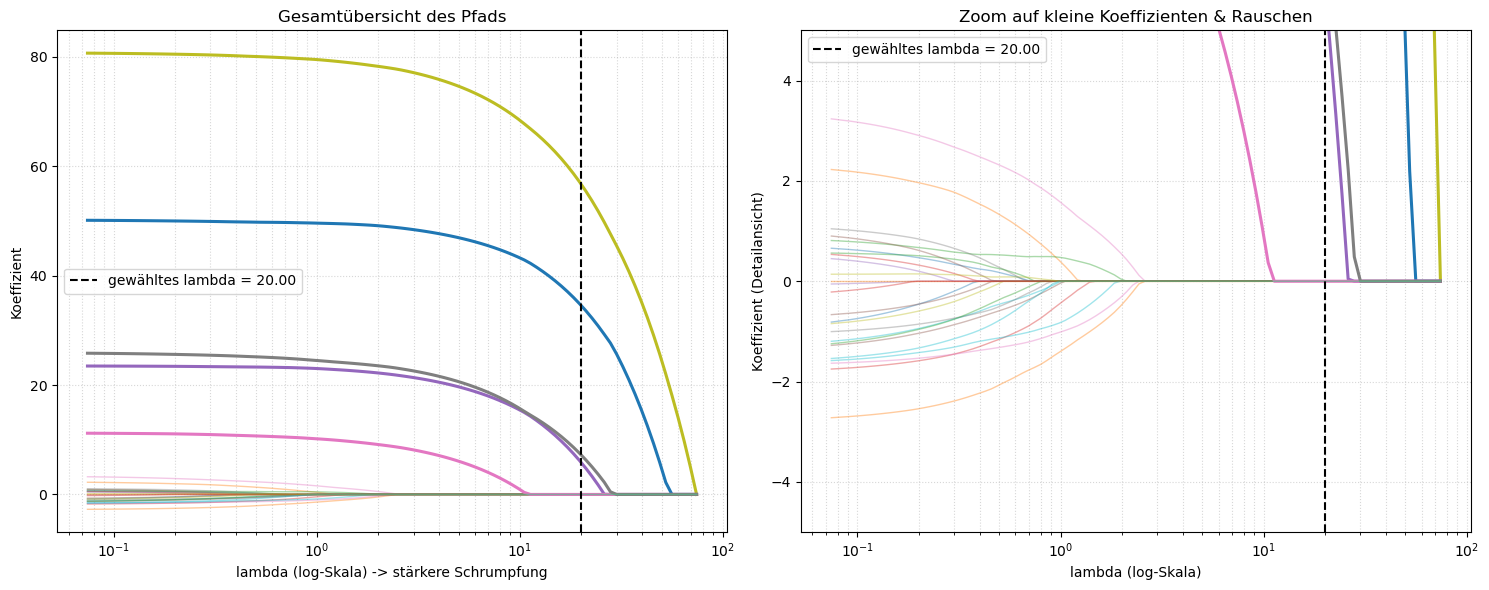

In [17]:
# Wir erstellen ein Grid mit 1 Zeile und 2 Spalten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Schleife über alle Koeffizienten-Pfade
for j in range(coefs.shape[0]):
    echt = j in echte_variablen
    # Style-Zuweisung für bessere Sichtbarkeit
    linewidth = 2.2 if echt else 1.0
    alpha_val = 1.0 if echt else 0.4
    
    # Plot auf dem linken (normalen) Graph
    ax1.plot(alphas, coefs[j], lw=linewidth, alpha=alpha_val)
    # Plot auf dem rechten (eingezoomten) Graph
    ax2.plot(alphas, coefs[j], lw=linewidth, alpha=alpha_val)

# --- Formatierung für Graph 1 (Gesamtübersicht) ---
ax1.axvline(lam, color="black", ls="--", label=f"gewähltes lambda = {lam:.2f}")
ax1.set_xscale("log")
ax1.set_xlabel("lambda (log-Skala) -> stärkere Schrumpfung")
ax1.set_ylabel("Koeffizient")
ax1.set_title("Gesamtübersicht des Pfads")
ax1.legend()
ax1.grid(True, which="both", ls=":", alpha=0.5)

# --- Formatierung für Graph 2 (Der ZOOM auf das Rauschen) ---
ax2.axvline(lam, color="black", ls="--", label=f"gewähltes lambda = {lam:.2f}")
ax2.set_xscale("log")
ax2.set_xlabel("lambda (log-Skala)")
ax2.set_ylabel("Koeffizient (Detailansicht)")
ax2.set_title("Zoom auf kleine Koeffizienten & Rauschen")
ax2.legend()
ax2.grid(True, which="both", ls=":", alpha=0.5)

# HIER PASSIERT DER ZOOM: Wir begrenzen die Y-Achse auf den Bereich um die Null
# (Falls -5 bis 5 nicht reicht, einfach die Zahlen anpassen)
ax2.set_ylim(-5, 5) 

plt.tight_layout()
plt.savefig("bild2.png", dpi=300, bbox_inches="tight")
plt.show()

Loss contour surfaces with l1 constraint regions.


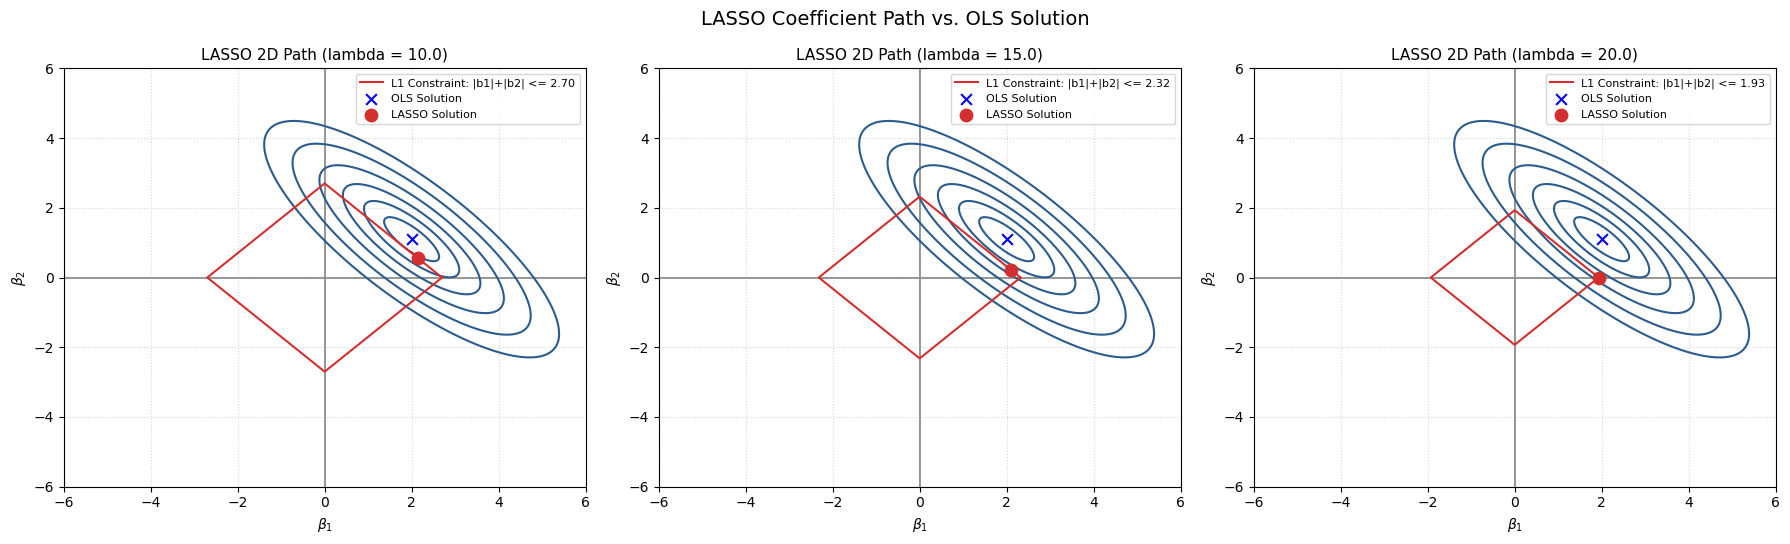

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Parameter für die OLS-Verlustfunktion (Ellipse) definieren
# Zentrum der Ellipse (unregulierte OLS-Lösung)
beta_ols = np.array([2.0, 1.1])

# Kovarianzmatrix-Struktur für die Ausrichtung der Ellipse (gedreht/langgezogen)
# Ein hoher Wert außerhalb der Diagonale sorgt für die Schräglage
Sigma = np.array([[1.0, -0.8], [-0.8, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)


def ols_loss(B1, B2):
    """Berechnet die quadratische Verlustfunktion für das Gitter."""
    diff_1 = B1 - beta_ols[0]
    diff_2 = B2 - beta_ols[1]
    # Matrix-Multiplikation auf dem Gitter für die Ellipsenform
    return (
        Sigma_inv[0, 0] * diff_1**2
        + (Sigma_inv[0, 1] + Sigma_inv[1, 0]) * diff_1 * diff_2
        + Sigma_inv[1, 1] * diff_2**2
    )


# 2. Gitter für die Konturlinien erstellen
beta1_vals = np.linspace(-6, 6, 400)
beta2_vals = np.linspace(-6, 6, 400)
B1, B2 = np.meshgrid(beta1_vals, beta2_vals)
Z = ols_loss(B1, B2)

# 3. Die drei Lambda-Szenarien definieren (Größe der Raute)
# Je größer Lambda im echten Lasso, desto kleiner das erlaubte Budget 't'
lambdas = [10.0, 15.0, 20.0]
budgets = [2.70, 2.32, 1.93]

# Die exakten Berührungspunkte (Lasso-Lösungen) manuell für die Grafik gesetzt
# Im echten Leben berechnet Lasso diese Punkte über Optimierungsalgorithmen
lasso_solutions = [[2.15, 0.55], [2.10, 0.22], [1.93, 0.0]]

# 4. Plot erstellen (1 Zeile, 3 Spalten)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("LASSO Coefficient Path vs. OLS Solution", fontsize=14)

for i, ax in enumerate(axes):
    lam = lambdas[i]
    t = budgets[i]
    sol = lasso_solutions[i]

    # Gitterlinien im Hintergrund
    ax.grid(True, which="both", ls=":", alpha=0.5)

    # --- OLS Konturlinien (Ellipsen) zeichnen ---
    # levels bestimmt die Abstände der Ringe
    contours = ax.contour(
        B1,
        B2,
        Z,
        levels=[0.4, 1.2, 2.5, 4.5, 7.5, 11.5],
        colors="#2b5c8f",
        linewidths=1.5,
    )

    # --- L1-Constraint (Raute) zeichnen ---
    # Die Ecken der Raute liegen bei (t,0), (0,t), (-t,0), (0,-t)
    diamond_x = [t, 0, -t, 0, t]
    diamond_y = [0, t, 0, -t, 0]
    ax.plot(
        diamond_x,
        diamond_y,
        color="#d32f2f",
        lw=1.5,
        label=f"L1 Constraint: |b1|+|b2| <= {t:.2f}",
    )

    # --- OLS Lösung (Blaues Kreuz) ---
    ax.scatter(
        beta_ols[0],
        beta_ols[1],
        color="blue",
        marker="x",
        s=60,
        label="OLS Solution",
        zorder=5,
    )

    # --- LASSO Lösung (Roter Punkt) ---
    ax.scatter(
        sol[0],
        sol[1],
        color="#d32f2f",
        marker="o",
        s=80,
        label="LASSO Solution",
        zorder=5,
    )

    # Achsen-Einstellungen
    ax.axhline(0, color="gray", lw=1.2, zorder=1)
    ax.axvline(0, color="gray", lw=1.2, zorder=1)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_title(f"LASSO 2D Path (lambda = {lam:.1f})", fontsize=11)

    # Legende oben rechts platzieren
    ax.legend(loc="upper right", fontsize=8, framealpha=0.8)

plt.tight_layout()
print("Loss contour surfaces with l1 constraint regions.")
plt.savefig("bild3.png", dpi=300, bbox_inches="tight")
plt.show()

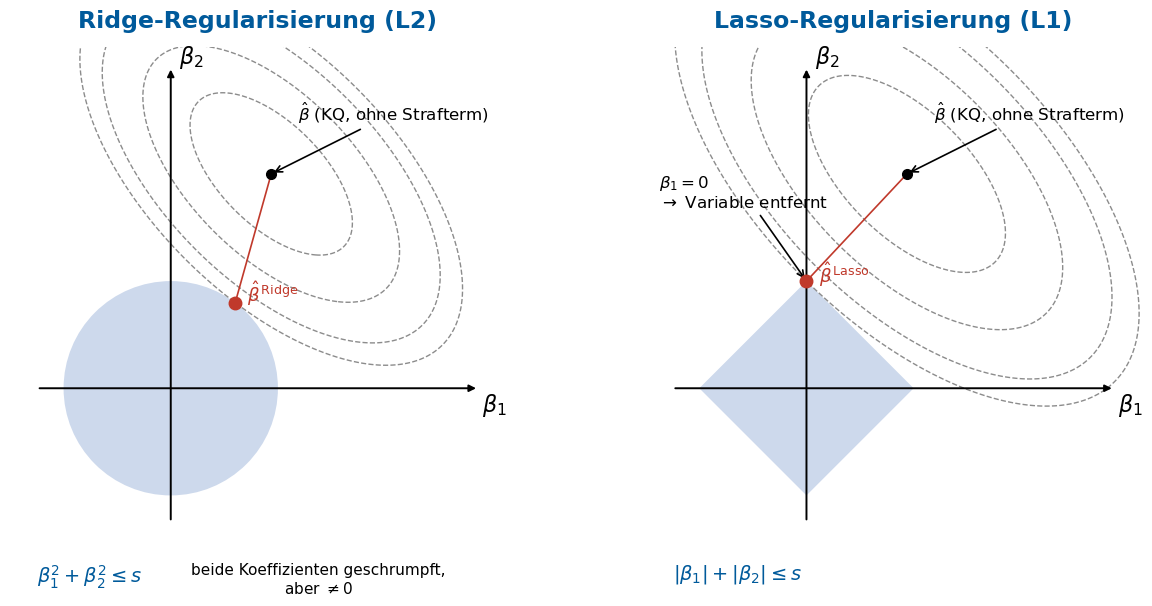

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon

THI_BLAU, ROT, FILL = "#005a9b", "#c0392b", "#cdd9ec"

# Eine gemeinsame Ellipse fuer BEIDE Panels: gleiches Zentrum + gleiche Form
beta_ols = np.array([1.5, 3.2])
A = np.array([[1.0, 0.60], [0.60, 1.0]])   # lange Achse entlang Anti-Diagonale
r = s = 1.6

def rss(b1, b2):
    d1, d2 = b1 - beta_ols[0], b2 - beta_ols[1]
    return A[0,0]*d1*d1 + 2*A[0,1]*d1*d2 + A[1,1]*d2*d2

def diamond_pts(s, n=16000):
    v = np.array([[s,0],[0,s],[-s,0],[0,-s],[s,0]]); out = []
    for k in range(4):
        a, b = v[k], v[k+1]; seg = np.linspace(0, 1, n//4)
        out.append(np.outer(1-seg, a) + np.outer(seg, b))
    return np.vstack(out)

def achsen(ax):
    ax.annotate("", xy=(4.6,0), xytext=(-2.0,0), arrowprops=dict(arrowstyle="-|>", color="k", lw=1.4))
    ax.annotate("", xy=(0,4.8), xytext=(0,-2.0), arrowprops=dict(arrowstyle="-|>", color="k", lw=1.4))
    ax.text(4.65, -0.05, r"$\beta_1$", fontsize=16, va="top")
    ax.text(0.12, 4.85, r"$\beta_2$", fontsize=16, ha="left")

def konturen(ax, lvl):
    g = np.linspace(-2.5, 5.2, 500); B1, B2 = np.meshgrid(g, g)
    ax.contour(B1, B2, rss(B1, B2), levels=lvl, colors="0.55", linestyles="--", linewidths=1.0)

# Tangentenpunkte numerisch (Minimum der RSS auf dem Rand der Restriktionsmenge)
t = np.linspace(0, 2*np.pi, 16000); cx, cy = r*np.cos(t), r*np.sin(t)
ridge = np.array([cx, cy]).T[np.argmin(rss(cx, cy))]
P = diamond_pts(s); lasso = P[np.argmin(rss(P[:,0], P[:,1]))]
cs, cs2 = rss(*ridge), rss(*lasso)
lvlR = sorted([0.18*cs,  0.45*cs,  0.78*cs,  cs])
lvlL = sorted([0.18*cs2, 0.45*cs2, 0.78*cs2, cs2])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6.2))

# ---------------- Ridge (L2) ----------------
axL.add_patch(Circle((0,0), r, facecolor=FILL, edgecolor="none", zorder=0))
konturen(axL, lvlR); achsen(axL)
axL.plot([beta_ols[0], ridge[0]], [beta_ols[1], ridge[1]], color=ROT, lw=1.2, zorder=3)
axL.plot(*beta_ols, "ko", ms=7, zorder=4); axL.plot(*ridge, "o", color=ROT, ms=9, zorder=5)
axL.annotate(r"$\hat{\beta}$ (KQ, ohne Strafterm)", xy=beta_ols, xytext=(1.9, 4.0), fontsize=12,
             arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
axL.text(ridge[0]+0.18, ridge[1]+0.02, r"$\hat{\beta}^{\,\mathrm{Ridge}}$", color=ROT, fontsize=13)
axL.text(2.2, -2.6, "beide Koeffizienten geschrumpft,\naber $\\neq 0$", ha="center", va="top", fontsize=11)
axL.text(-2.0, -2.6, r"$\beta_1^2 + \beta_2^2 \leq s$", color=THI_BLAU, fontsize=14, va="top")
axL.set_title("Ridge-Regularisierung (L2)", color=THI_BLAU, fontsize=17, fontweight="bold", pad=14)

# ---------------- Lasso (L1) ----------------
axR.add_patch(Polygon([[s,0],[0,s],[-s,0],[0,-s]], closed=True, facecolor=FILL, edgecolor="none", zorder=0))
konturen(axR, lvlL); achsen(axR)
axR.plot([beta_ols[0], lasso[0]], [beta_ols[1], lasso[1]], color=ROT, lw=1.2, zorder=3)
axR.plot(*beta_ols, "ko", ms=7, zorder=4); axR.plot(*lasso, "o", color=ROT, ms=9, zorder=5)
axR.annotate(r"$\hat{\beta}$ (KQ, ohne Strafterm)", xy=beta_ols, xytext=(1.9, 4.0), fontsize=12,
             arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
axR.annotate("$\\beta_1 = 0$\n$\\rightarrow$ Variable entfernt", xy=lasso, xytext=(-2.2, 2.7), fontsize=12,
             arrowprops=dict(arrowstyle="->", color="k", lw=1.2))
axR.text(lasso[0]+0.18, lasso[1]-0.02, r"$\hat{\beta}^{\,\mathrm{Lasso}}$", color=ROT, fontsize=13)
axR.text(-2.0, -2.6, r"$|\beta_1| + |\beta_2| \leq s$", color=THI_BLAU, fontsize=14, va="top")
axR.set_title("Lasso-Regularisierung (L1)", color=THI_BLAU, fontsize=17, fontweight="bold", pad=14)

for ax in (axL, axR):
    ax.set_xlim(-2.4, 5.0); ax.set_ylim(-3.0, 5.1); ax.set_aspect("equal"); ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Die CV-Kurve

Der Kreuzvalidierungs-Fehler ist U-foermig: zu kleines $\lambda$ ueberanpasst,
zu grosses unteranpasst. Das Minimum legt $\lambda$ fest.

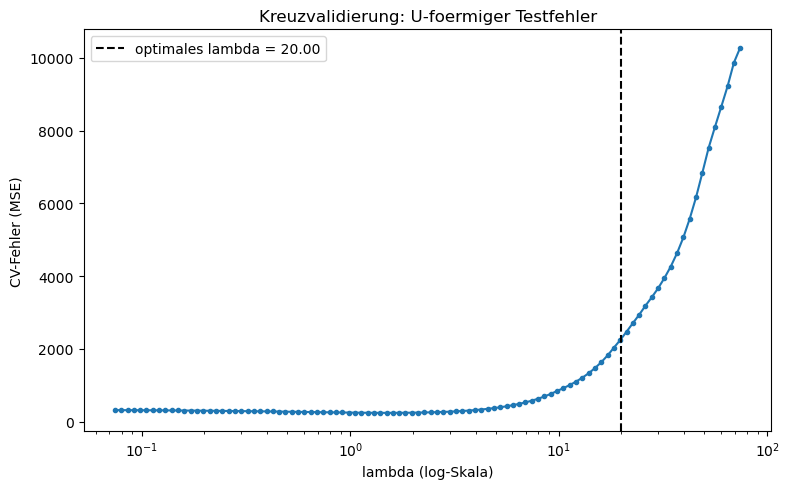

In [19]:
mse_mean = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso_cv.alphas_, mse_mean, marker="o", ms=3)
plt.axvline(lam, color="black", ls="--", label=f"optimales lambda = {lam:.2f}")
plt.xscale("log")
plt.xlabel("lambda (log-Skala)"); plt.ylabel("CV-Fehler (MSE)")
plt.title("Kreuzvalidierung: U-foermiger Testfehler")
plt.legend(); plt.tight_layout();
plt.savefig("bild4.png", dpi=300, bbox_inches="tight")
plt.show()

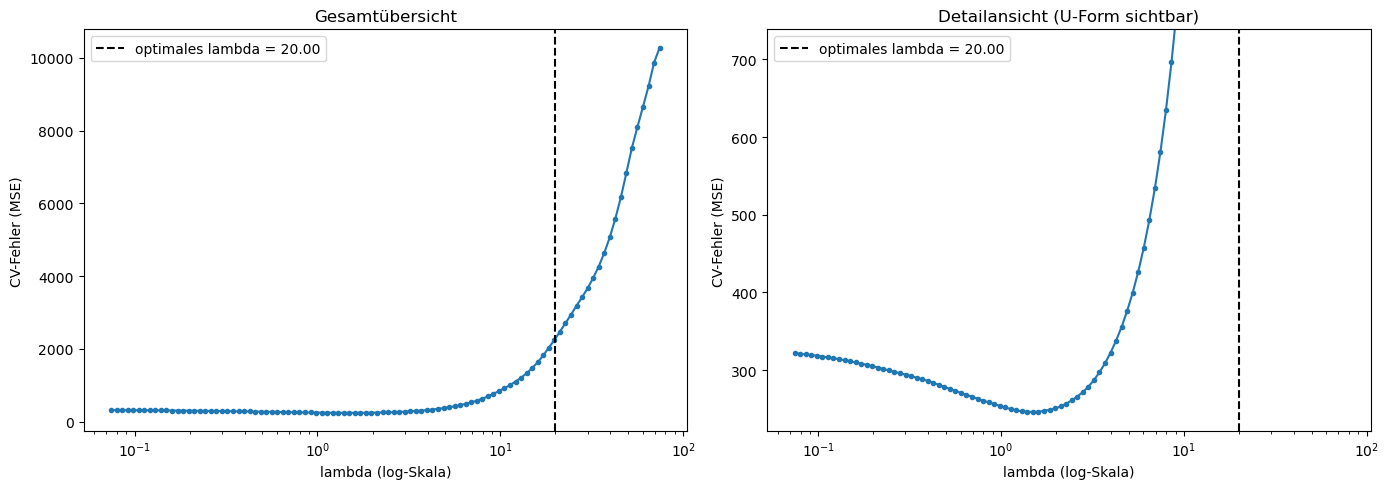

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Graph: Komplette Übersicht (wie bisher)
ax1.plot(lasso_cv.alphas_, mse_mean, marker="o", ms=3)
ax1.axvline(lam, color="black", ls="--", label=f"optimales lambda = {lam:.2f}")
ax1.set_xscale("log")
ax1.set_xlabel("lambda (log-Skala)")
ax1.set_ylabel("CV-Fehler (MSE)")
ax1.set_title("Gesamtübersicht")
ax1.legend()

# 2. Graph: Detailansicht (Zoom auf die U-Kurve)
ax2.plot(lasso_cv.alphas_, mse_mean, marker="o", ms=3)
ax2.axvline(lam, color="black", ls="--", label=f"optimales lambda = {lam:.2f}")
ax2.set_xscale("log")

# Zoom auf den relevanten Bereich der y-Achse
# Setzt das Maximum z.B. auf das 3-fache des minimalen Fehlers
min_mse = mse_mean.min()
ax2.set_ylim(min_mse * 0.9, min_mse * 3) 

ax2.set_xlabel("lambda (log-Skala)")
ax2.set_ylabel("CV-Fehler (MSE)")
ax2.set_title("Detailansicht (U-Form sichtbar)")
ax2.legend()

plt.tight_layout()
plt.savefig("bild5.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Ridge vs. Lasso -- nur Lasso erzeugt Nullen

Bei gleichem $\lambda$ schrumpft Ridge alle Koeffizienten, setzt aber keinen auf
exakt null. Lasso dagegen schon.

*(Die alpha-Skalen von Ridge und Lasso sind nicht direkt vergleichbar -- es geht
hier nur um das qualitative Verhalten.)*

Koeffizienten != 0 bei Ridge: 30 von 30
Koeffizienten != 0 bei Lasso: 4 von 30


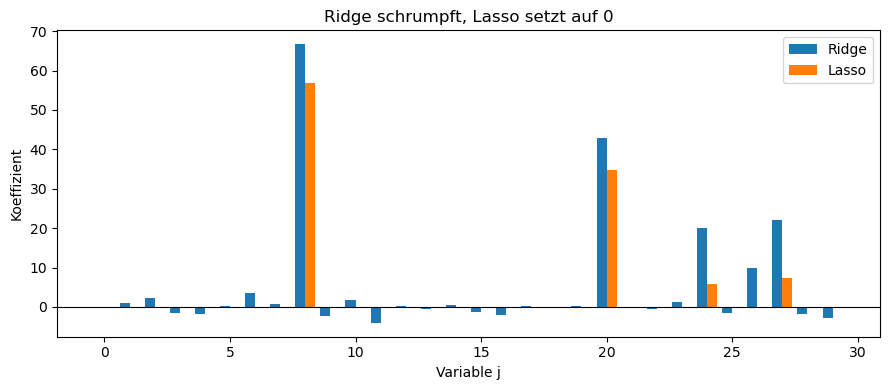

In [13]:
ridge = Ridge(alpha=lam).fit(X, y)
lasso = Lasso(alpha=lam).fit(X, y)
print("Koeffizienten != 0 bei Ridge:", int(np.sum(np.abs(ridge.coef_) > 1e-8)), f"von {p}")
print("Koeffizienten != 0 bei Lasso:", int(np.sum(np.abs(lasso.coef_) > 1e-8)), f"von {p}")

idx = np.arange(p)
plt.figure(figsize=(9, 4))
plt.bar(idx - 0.2, ridge.coef_, width=0.4, label="Ridge")
plt.bar(idx + 0.2, lasso.coef_, width=0.4, label="Lasso")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Variable j"); plt.ylabel("Koeffizient")
plt.title("Ridge schrumpft, Lasso setzt auf 0")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
# 2. Modelle mit statsmodels fitten
# L1_wt=0.0 erzwingt Ridge (L2-Regularisierung)
ridge_model = sm.OLS(y, X_with_constant).fit_regularized(alpha=lam, L1_wt=0.0)

# L1_wt=1.0 erzwingt Lasso (L1-Regularisierung)
lasso_model = sm.OLS(y, X_with_constant).fit_regularized(alpha=lam, L1_wt=1.0)

# 3. Koeffizienten extrahieren (ohne den Intercept an Index 0)
ridge_coefs = ridge_model.params[1:]
lasso_coefs = lasso_model.params[1:]

# 4. Konsolen-Ausgabe analog zu deinem Screenshot
print(
    "Koeffizienten != 0 bei Ridge:",
    int(np.sum(np.abs(ridge_coefs) > 1e-8)),
    f"von {p}",
)
print(
    "Koeffizienten != 0 bei Lasso:",
    int(np.sum(np.abs(lasso_coefs) > 1e-8)),
    f"von {p}",
)

Koeffizienten != 0 bei Ridge: 30 von 30
Koeffizienten != 0 bei Lasso: 4 von 30


In [15]:
print(lasso_model.summary())

NotImplementedError: 

**Warum geht das nicht?**

In statsmodels ist die .summary()-Tabelle (mit p-Werten, Standardfehlern, Konfidenzintervallen etc.) für regularisierte Modelle (Ridge und Lasso) nicht implementiert.

Das hat einen mathematischen Grund: Durch die Regularisierung (die künstliche Schrumpfung der Koeffizienten) sind die klassischen statistischen Standardfehler verzerrt (biased). Da es in der Statistik keinen einfachen, allgemeingültigen Konsens darüber gibt, wie man p-Werte für Ridge/Lasso korrekt berechnet, blockiert statsmodels den Aufruf von .summary() an dieser Stelle komplett.

In [21]:
# Gibt ein Pandas-Series-Objekt mit allen Werten aus (inklusive der Konstante 'const')
print(ridge_model.params)

[ 0.22093671  0.17013681 -0.32999227  0.58459122 -0.33299711 -0.27812394
  0.28641979  0.42206221 -0.02009394  3.52597455 -0.52494963  0.36937355
 -0.40933253  0.00822032 -0.24000228 -0.3462336  -0.07996205 -0.31025402
  0.47061029  0.11746597  0.17314105  2.53193517  0.07494001 -0.1106105
  0.62565376  1.16248317 -0.73557818  0.49602749  1.39048404 -0.40365816
 -0.45208214]


In [22]:
# Gibt ein Pandas-Series-Objekt mit allen Werten aus (inklusive der Konstante 'const')
print(lasso_model.params)

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.         56.82387773  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         34.626805    0.          0.
  0.          5.92387555  0.          0.          7.29459038  0.
  0.        ]


### Der Post-Lasso-Workflow (p-Werte trotz Regularisierung)

Falls du unbedingt **$p$-Werte** und Konfidenzintervalle benötigst, nutzt man in der Praxis diesen zweistufigen Workflow:

1. **Schritt 1: Variablen-Selektion via Lasso**
   * Du fittest eine Lasso-Regression mittels `.fit_regularized(L1_wt=1.0)`.
   * Alle Variablen, deren Koeffizienten auf exakt Null geschrumpft werden (z. B. deine 15 Rausch-Variablen), fliegen aus dem Datensatz raus.
   
2. **Schritt 2: Refit via OLS ("Post-Lasso")**
   * Du nimmst **nur noch** die Variablen, die das Lasso im ersten Schritt übrig gelassen hat.
   * Mit dieser reduzierten Auswahl fittest du ein ganz normales, unregularisiertes OLS-Modell via `.fit()`.
   * Für dieses finale Modell funktioniert `model.summary()` wieder tadellos und liefert dir alle gewünschten statistischen Tests.

> **Hinweis:** Dieser Ansatz ist in der Ökonometrie und Statistik als **Post-Lasso** bekannt. Er verhindert, dass die $p$-Werte durch die künstliche L1-Schrumpfung verzerrt werden.

In [23]:
# ==============================================================================
# SCHRITT 1: Variablen-Selektion via Lasso
# ==============================================================================

# Lasso-Modell fitten (L1_wt=1.0 erzwingt reines Lasso)
# 'lam' ist dein über Kreuzvalidierung gefundenes, optimales Lambda
lasso_model = sm.OLS(y, X_with_constant).fit_regularized(alpha=lam, L1_wt=1.0)

# Koeffizienten extrahieren (ohne den Intercept an Index 0)
lasso_coefs = lasso_model.params[1:]

# Indizes der Variablen bestimmen, die NICHT auf Null geschrumpft wurden
ausgewaehlte_indizes = np.flatnonzero(np.abs(lasso_coefs) > 1e-8)

print(f"Lasso hat {len(ausgewaehlte_indizes)} von {p} Variablen ausgewählt.")
print(f"Ausgewählte Variablen-Indizes: {ausgewaehlte_indizes}\n")


# ==============================================================================
# SCHRITT 2: Refit via OLS ("Post-Lasso") für die .summary()
# ==============================================================================

# Nur die Spalten aus X herausschneiden, die das Lasso ausgewählt hat
X_reduziert = X[:, ausgewaehlte_indizes]

# Für das neue OLS-Modell wieder eine Konstante (Intercept) hinzufügen
X_reduziert_with_constant = sm.add_constant(X_reduziert)

# Namen für die Tabelle vergeben, damit man x0, x1 etc. im Summary zuordnen kann
# 'const' ist immer an Index 0, danach folgen die echten Indizes
spalten_namen = ["const"] + [f"x{idx}" for idx in ausgewaehlte_indizes]

if isinstance(X, pd.DataFrame):
    # Falls dein X ein DataFrame ist, nutzen wir die echten Spaltennamen
    spalten_namen = ["const"] + [X.columns[idx] for idx in ausgewaehlte_indizes]

# Das unregularisierte OLS-Modell NUR mit den relevanten Variablen fitten
post_lasso_model = sm.OLS(y, X_reduziert_with_constant).fit()

# Verfeinerte Spaltennamen der Ergebnistabelle zuweisen
post_lasso_model.model.exog_names[:] = spalten_namen

# Jetzt funktioniert die Summary einwandfrei inklusive p-Werten!
print(post_lasso_model.summary())

Lasso hat 4 von 30 Variablen ausgewählt.
Ausgewählte Variablen-Indizes: [ 8 20 24 27]

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     922.1
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.43e-86
Time:                        08:13:22   Log-Likelihood:                -515.22
No. Observations:                 120   AIC:                             1040.
Df Residuals:                     115   BIC:                             1054.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

## Zum Mitnehmen

- Lasso liefert ein **sparsames** Modell: irrelevante Variablen bekommen den
  Koeffizienten exakt null.
- $\lambda$ steuert die Staerke und wird per **Kreuzvalidierung** gewaehlt.
- $\lambda \to 0$: zurueck zu OLS (wenig Bias, viel Varianz).
  $\lambda \to \infty$: alle Koeffizienten null (viel Bias, wenig Varianz).

> **Übung:** Aus einer Koeffizienten-Tabelle ablesen, welche Variablen bei
> einem gegebenen $\lambda$ im Modell sind und in welcher Reihenfolge sie
> herausfallen - macht der Pfad oben sichtbar.